In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")

### Task 1: Build and Summarize Synthetic Datasets

Start by creating three synthetic datasets that represent different distribution shapes. Each dataset should have **500** observations.

1. **Dataset A** — Symmetric: draw from a normal distribution with mean = 50 and standard deviation = 10.
2. **Dataset B** — Right-skewed: draw from an exponential distribution, then shift and scale so the values fall roughly in the 0–100 range.
3. **Dataset C** — Bimodal: combine two normal distributions (e.g., means at 30 and 70) with equal sample sizes.

For each dataset, compute and display in a summary table:
- Mean, median, mode (rounded to 2 decimals)
- Standard deviation, variance, IQR
- Skewness and kurtosis (use `scipy.stats.skew` and `scipy.stats.kurtosis`)

**Guiding question:** Which summary statistics look similar across the three datasets, and which reveal the differences?

In [2]:
# 1. Dataset A - Symmetric (Normal)
data_a = np.random.normal(loc=50, scale=10, size=500)

# 2. Dataset B - Right-skewed (Exponential)
data_b = np.random.exponential(scale=20, size=500)

# 3. Dataset C - Bimodal (Two Normals)
data_c1 = np.random.normal(loc=30, scale=5, size=250)
data_c2 = np.random.normal(loc=70, scale=5, size=250)
data_c = np.concatenate([data_c1, data_c2])

datasets = {'Symmetric': data_a, 'Right-Skewed': data_b, 'Bimodal': data_c}

# Compute Statistics
stats_list = []
for name, data in datasets.items():
    stats_list.append({
        'Dataset': name,
        'Mean': np.round(np.mean(data), 2),
        'Median': np.round(np.median(data), 2),
        'Mode': np.round(stats.mode(data, keepdims=True)[0][0], 2),
        'Std Dev': np.round(np.std(data), 2),
        'Variance': np.round(np.var(data), 2),
        'IQR': np.round(stats.iqr(data), 2),
        'Skewness': np.round(stats.skew(data), 2),
        'Kurtosis': np.round(stats.kurtosis(data), 2)
    })

df_stats = pd.DataFrame(stats_list)
display(df_stats)

,Dataset,Mean,Median,Mode,Std Dev,Variance,IQR,Skewness,Kurtosis
0,Symmetric,50.07,50.13,17.59,9.80,96.09,13.37,0.18,0.26
1,Right-Skewed,20.07,14.04,0.09,19.73,389.45,23.05,1.77,3.98
2,Bimodal,50.33,49.53,15.52,20.28,411.19,39.01,0.01,-1.76


**Observation:** The **Skewness** value clearly distinguishes the Right-Skewed dataset from the others, while the **Mean and Median** are nearly identical in the Symmetric and Bimodal sets despite their very different shapes.

### Task 2: Visualize the Distributions

Create a figure with **three rows and three columns** (9 subplots total). Each row represents one dataset (A, B, C). The columns are:

1. **Histogram** with 30 bins and a KDE overlay.
2. **Boxplot** (horizontal orientation).
3. **KDE plot** alone, with vertical lines marking the mean (dashed red) and median (solid blue).

Add clear titles and axis labels to every subplot. Use `plt.tight_layout()` to prevent overlap.

**Guiding question:** For which dataset(s) do the mean and median diverge the most? What visual feature explains the divergence?

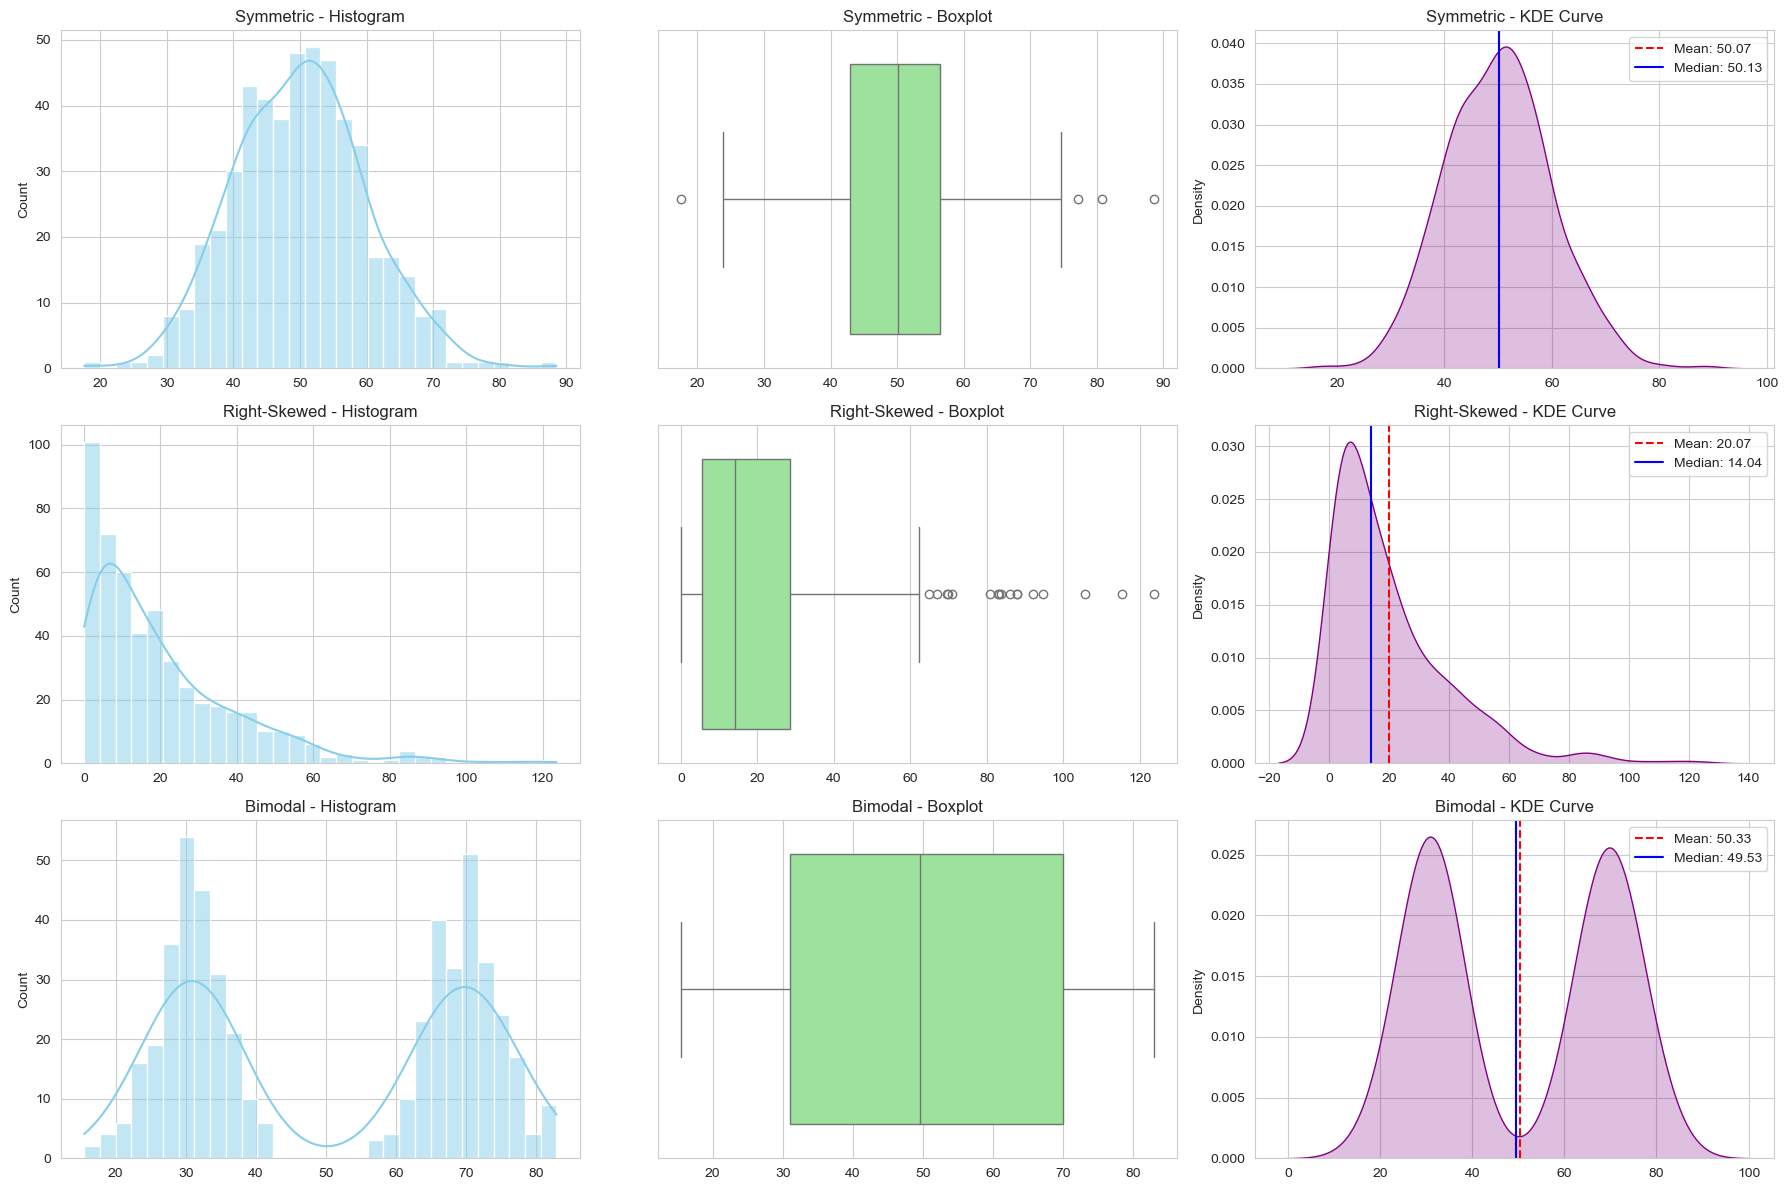

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for i, (name, data) in enumerate(datasets.items()):
    # Column 1: Histogram
    sns.histplot(data, bins=30, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{name} - Histogram')
    
    # Column 2: Boxplot
    sns.boxplot(x=data, ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'{name} - Boxplot')
    
    # Column 3: KDE with Mean/Median
    sns.kdeplot(data, ax=axes[i, 2], fill=True, color='purple')
    axes[i, 2].axvline(np.mean(data), color='red', linestyle='--', label=f'Mean: {np.mean(data):.2f}')
    axes[i, 2].axvline(np.median(data), color='blue', linestyle='-', label=f'Median: {np.median(data):.2f}')
    axes[i, 2].set_title(f'{name} - KDE Curve')
    axes[i, 2].legend()

plt.tight_layout()
plt.show()

**Guiding Question Answer:** The mean and median diverge most in the **Right-Skewed** dataset. The "long tail" of high values pulls the mean to the right, while the median remains closer to the bulk of the data.

### Task 3: The Outlier Stress Test

Take **Dataset A** (the symmetric one) and create a modified copy:

1. Replace the **5 largest values** with extreme outliers: multiply each by 10.
2. Compute the same summary statistics table as Task 1 for both the original and modified versions.
3. Create side-by-side boxplots (original vs. modified) and overlay the mean as a diamond marker on each.

Answer the following in a markdown cell:
- Which statistics changed the most? Which were robust?
- If you were reporting a "typical" value for the modified dataset, would you choose the mean or the median? Why?

,Version,Mean,Median,Std Dev,IQR
0,Original,50.068380,50.127971,9.802715,13.370907
1,With Outliers,57.165723,50.127971,74.306225,13.370907


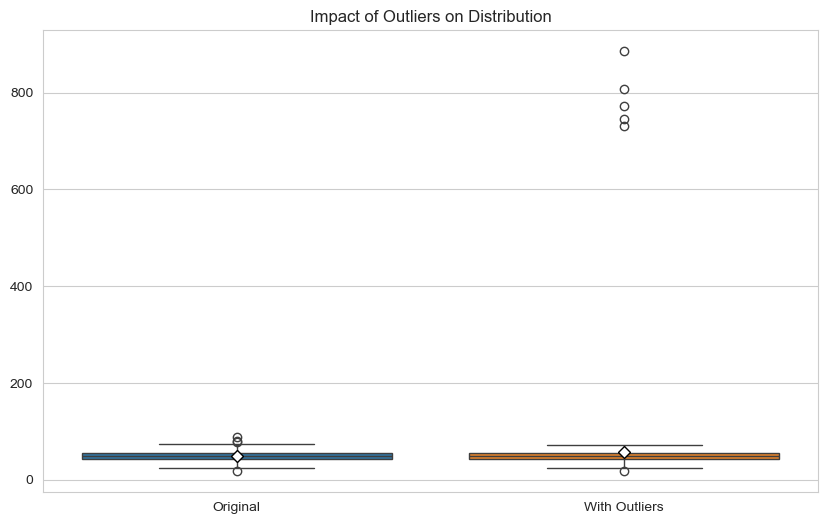

In [4]:
# Create modified copy
data_a_outliers = data_a.copy()
# Identify 5 largest values and multiply by 10
top_indices = np.argsort(data_a_outliers)[-5:]
data_a_outliers[top_indices] *= 10

# Summary Comparison
comparison = []
for label, d in [("Original", data_a), ("With Outliers", data_a_outliers)]:
    comparison.append({
        "Version": label,
        "Mean": np.mean(d),
        "Median": np.median(d),
        "Std Dev": np.std(d),
        "IQR": stats.iqr(d)
    })

display(pd.DataFrame(comparison))

# Side-by-side Boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=[data_a, data_a_outliers], showmeans=True, 
            meanprops={"marker":"D","markerfacecolor":"white", "markeredgecolor":"black"})
plt.xticks([0, 1], ['Original', 'With Outliers'])
plt.title("Impact of Outliers on Distribution")
plt.show()

* **Which statistics changed the most?** The **Mean** and **Standard Deviation** are highly sensitive; they spiked significantly because they factor in the magnitude of every value.
* **Which were robust?** The **Median** and **IQR** remained stable. Since they depend on the *rank* or *position* of values rather than their specific weight, the extreme outliers did not shift them much.
* **Reporting Choice:** For the modified dataset, I would choose the **Median** to represent the "typical" value. The Mean is currently inflated by a few extreme points and no longer represents the center of the 495 other observations.